In [1]:
!git clone https://github.com/AGupta-23/RetinaVision.git
%cd RetinaVision

Cloning into 'RetinaVision'...
remote: Enumerating objects: 61, done.
remote: Total 61 (delta 0), reused 0 (delta 0), pack-reused 61 (from 1)
Receiving objects: 100% (61/61), 88.10 MiB | 39.72 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/kaggle/working/RetinaVision


In [2]:
import torch
import pandas as pd
from torch.utils.data import DataLoader

from src.model import build_model
from src.dataset import RetinaDataset, preprocess_transform

TEST_CSV = "/kaggle/working/RetinaVision/data/test_split.csv"
MODEL_PATH = "/kaggle/working/RetinaVision/models/best_model.pth"
IMG_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection/train_images"

# --- Load test data ---
test_df = pd.read_csv(TEST_CSV)
print(test_df.shape)
print(test_df.head())

test_dataset = RetinaDataset(
    df=test_df,
    image_dir=IMG_DIR,
    transform=preprocess_transform
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- Load model + checkpoint ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print(f"Model loaded on {device}, test set has {len(test_dataset)} images.")

(550, 2)
       filename  label
0  ae2c3f6312ef      0
1  44e951e45dca      1
2  ef8c39eb9157      0
3  0e0003ddd8df      0
4  04579e31e4be      0
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Model loaded on cuda, test set has 550 images.


In [3]:
import numpy as np

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images).squeeze(1)       # shape: (batch,)
        probs = torch.sigmoid(logits)            # convert to probability
        preds = (probs >= 0.5).float()            # threshold at 0.5

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"Total predictions: {len(all_preds)}")
print(f"Sample probs:  {all_probs[:5]}")
print(f"Sample preds:  {all_preds[:5]}")
print(f"Sample labels: {all_labels[:5]}")

Total predictions: 550
Sample probs:  [1.3402812e-04 9.6331728e-01 1.0593112e-04 3.7556461e-03 3.2099017e-03]
Sample preds:  [0. 1. 0. 0. 0.]
Sample labels: [0. 1. 0. 0. 0.]


In [4]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)

print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

print("\nFull classification report:")
print(classification_report(all_labels, all_preds, target_names=["No DR", "DR"]))

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion matrix:")
print(cm)

Accuracy:  0.9618
F1-score:  0.9623
Precision: 0.9640
Recall:    0.9606

Full classification report:
              precision    recall  f1-score   support

       No DR       0.96      0.96      0.96       271
          DR       0.96      0.96      0.96       279

    accuracy                           0.96       550
   macro avg       0.96      0.96      0.96       550
weighted avg       0.96      0.96      0.96       550


Confusion matrix:
[[261  10]
 [ 11 268]]


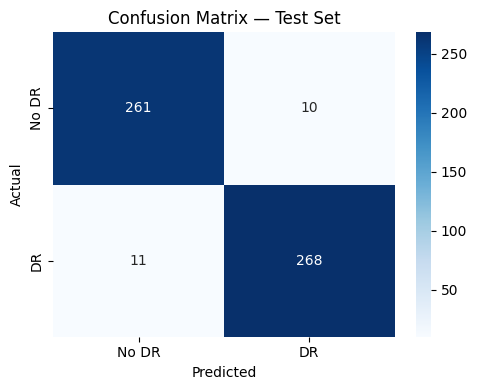

Saved confusion_matrix.png and test_metrics.json to outputs/


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No DR", "DR"], yticklabels=["No DR", "DR"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

# --- Save metrics as JSON for the README / report ---
import json

metrics = {
    "accuracy": float(accuracy),
    "f1_score": float(f1),
    "precision": float(precision),
    "recall": float(recall),
    "confusion_matrix": cm.tolist(),
    "test_set_size": len(all_labels)
}

with open("outputs/test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved confusion_matrix.png and test_metrics.json to outputs/")

In [6]:
test_df_result = test_df.copy()
test_df_result["pred"] = all_preds.astype(int)
test_df_result["prob"] = all_probs
test_df_result["correct"] = (test_df_result["label"] == test_df_result["pred"])

misclassified = test_df_result[~test_df_result["correct"]].copy()
misclassified["error_type"] = misclassified.apply(
    lambda r: "False Negative (missed DR)" if r["label"] == 1 else "False Positive",
    axis=1
)

print(f"Total misclassified: {len(misclassified)} / {len(test_df_result)}")
print(misclassified.sort_values("error_type"))

misclassified.to_csv("outputs/misclassified_samples.csv", index=False)
print("Saved misclassified_samples.csv to outputs/")

Total misclassified: 21 / 550
         filename  label  pred      prob  correct                  error_type
29   57469423a012      1     0  0.418956    False  False Negative (missed DR)
502  e9129ce55fd7      1     0  0.251903    False  False Negative (missed DR)
463  144a1a426137      1     0  0.395696    False  False Negative (missed DR)
390  27e4c800a449      1     0  0.476225    False  False Negative (missed DR)
535  259d30f693b6      1     0  0.041496    False  False Negative (missed DR)
279  365f8c01d994      1     0  0.013782    False  False Negative (missed DR)
114  bc73ce76ec43      1     0  0.087781    False  False Negative (missed DR)
549  367c7049929c      1     0  0.073138    False  False Negative (missed DR)
71   5548a7961a3e      1     0  0.291020    False  False Negative (missed DR)
31   310c27067ac0      1     0  0.264599    False  False Negative (missed DR)
90   e12b67835e03      1     0  0.008803    False  False Negative (missed DR)
265  cb02bb47fdc5      0     1  0.

In [7]:
from IPython.display import FileLink
display(FileLink("outputs/test_metrics.json"))
display(FileLink("outputs/confusion_matrix.png"))
display(FileLink("outputs/misclassified_samples.csv"))

/kaggle/working/RetinaVision/outputs/test_metrics.json

/kaggle/working/RetinaVision/outputs/confusion_matrix.png

/kaggle/working/RetinaVision/outputs/misclassified_samples.csv